## Installing and Importing Required Libraries

In [30]:

!pip install python-dotenv
!pip install anthropic

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
  Using cached docstring_parser-0.17.0-py3-none-any.whl.metadata (3.5 kB)
Using cached docstring_parser-0.17.0-py3-none-any.whl (36 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [anthropic]━ 1/2 [anthropic]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import base64
import os
import requests
import json
import re

from dotenv import load_dotenv
load_dotenv()

True

## Importing the Dataset

In [82]:
dataset = pd.read_csv("appliance_usage_dataset.csv",
                      encoding = 'utf-8')
dataset = dataset[:10000]
print(dataset.shape)
dataset.head()

(10000, 10)


,timestamp,house_id,season,festival,ac,fridge,lights,fans,washing_machine,tv
0,2023-01-01 00:00:00,House_1,winter,NaN,0.25,0.59,0.42,0.38,0.15,0.26
1,2023-01-01 01:00:00,House_1,winter,NaN,0.12,0.56,0.38,0.41,0.11,0.59
2,2023-01-01 02:00:00,House_1,winter,NaN,0.43,0.36,0.25,0.26,0.19,0.41
3,2023-01-01 03:00:00,House_1,winter,NaN,0.27,0.39,0.38,0.24,0.19,0.35
4,2023-01-01 04:00:00,House_1,winter,NaN,0.28,0.54,0.26,0.35,0.28,0.22


## Inserting Data in GridDB

### Creating a GridDB Connection

In [83]:
username = os.environ.get("username")
password = os.environ.get("password")
base_url = os.environ.get("base_url")


url = f"{base_url}/checkConnection"

credentials = f"{username}:{password}"
encoded_credentials = base64.b64encode(credentials.encode()).decode()

headers = {
    'Content-Type': 'application/json',  # Added this header to specify JSON content
    'Authorization': f'Basic {encoded_credentials}',
    'User-Agent': 'PostmanRuntime/7.29.0'
}

response = requests.get(url, headers=headers)

print(response.status_code)
print(response.text)

200



### Creating a GridDB Container for Electricity Consumption Data

In [84]:
dataset.insert(0, "SerialNo", dataset.index + 1)
dataset.columns.name = None   
# Mapping pandas dtypes to GridDB types
type_mapping = {
    "int64":          "LONG",
    "float64":        "DOUBLE",
    "bool":           "BOOL",
    'datetime64': "TIMESTAMP", 
    "object":         "STRING",
    "category":       "STRING",
}

# Generate the columns part of the payload dynamically
columns = []
for col, dtype in dataset.dtypes.items():
    griddb_type = type_mapping.get(str(dtype), "STRING")  # Default to STRING if unknown
    columns.append({
        "name": col,
        "type": griddb_type
    })

print(columns)

[{'name': 'SerialNo', 'type': 'LONG'}, {'name': 'timestamp', 'type': 'STRING'}, {'name': 'house_id', 'type': 'STRING'}, {'name': 'season', 'type': 'STRING'}, {'name': 'festival', 'type': 'STRING'}, {'name': 'ac', 'type': 'DOUBLE'}, {'name': 'fridge', 'type': 'DOUBLE'}, {'name': 'lights', 'type': 'DOUBLE'}, {'name': 'fans', 'type': 'DOUBLE'}, {'name': 'washing_machine', 'type': 'DOUBLE'}, {'name': 'tv', 'type': 'DOUBLE'}]


In [85]:
container_name = "electricity_consumption_db"

url = f"{base_url}/containers"

# Create the payload for the POST request
payload = json.dumps({
    "container_name": container_name,
    "container_type": "COLLECTION",
    "rowkey": True,  # Assuming the first column as rowkey
    "columns": columns
})


# Make the POST request to create the container
response = requests.post(url, headers=headers, data=payload)

# Print the response
print(f"Status Code: {response.status_code}")


Status Code: 201


### Inserting Data in Electricity Consumption GridDB Container

In [86]:
url = f"{base_url}/containers/{container_name}/rows"
# Convert dataset to list of lists (row-wise) with proper formatting

def format_row(row):
    formatted = []
    for item in row:
        if pd.isna(item):
            formatted.append(None)  # Convert NaN to None
        elif isinstance(item, bool):
            formatted.append(str(item).lower())  # Convert True/False to true/false
        elif isinstance(item, (int, float)):
            formatted.append(item)  # Keep integers and floats as they are
        else:
            formatted.append(str(item))  # Convert other types to string
    return formatted

# Prepare rows with correct formatting
rows = [format_row(row) for row in dataset.values.tolist()]

# Create payload as a JSON string
payload = json.dumps(rows)

# Make the PUT request to add the rows to the container
response = requests.put(url, headers=headers, data=payload)

# Print the response
print(f"Status Code: {response.status_code}")
print(f"Response Text: {response.text}")


Status Code: 200
Response Text: {"count":10000}


## Using AI to Monitor Electricity Consumption and Get Recommendations

### Retrieve Data from GridDB

In [87]:

url = f"{base_url}/containers/{container_name}/rows"

# Define the payload for the query
payload = json.dumps({
    "offset": 0,           # Start from the first row
    "limit": 10000,         # Limit the number of rows returned
    "condition": "",       # No filtering condition (you can customize it)
    "sort": ""             # No sorting (you can customize it)
})

# Make the POST request to read data from the container
response = requests.post(url, headers=headers, data=payload)

# Check response status and print output
print(f"Status Code: {response.status_code}")
if response.status_code == 200:
    try:
        data = response.json()
        print("Data retrieved successfully!")

        # Convert the response to a DataFrame
        rows = data.get("rows", [])
        electricity_consumption_db = pd.DataFrame(rows, columns=[col for col in dataset.columns])

    except json.JSONDecodeError:
        print("Error: Failed to decode JSON response.")
else:
    print(f"Error: Failed to query data from the container. Response: {response.text}")

print(electricity_consumption_db.shape)
electricity_consumption_db.head()

Status Code: 200
Data retrieved successfully!
(10000, 11)


,SerialNo,timestamp,house_id,season,festival,ac,fridge,lights,fans,washing_machine,tv
0,1,2023-01-01 00:00:00,House_1,winter,None,0.25,0.59,0.42,0.38,0.15,0.26
1,2,2023-01-01 01:00:00,House_1,winter,None,0.12,0.56,0.38,0.41,0.11,0.59
2,3,2023-01-01 02:00:00,House_1,winter,None,0.43,0.36,0.25,0.26,0.19,0.41
3,4,2023-01-01 03:00:00,House_1,winter,None,0.27,0.39,0.38,0.24,0.19,0.35
4,5,2023-01-01 04:00:00,House_1,winter,None,0.28,0.54,0.26,0.35,0.28,0.22


### Build Dataset Summary

In [88]:
import pandas as pd

APPLIANCE_COLS = ['ac', 'fridge', 'lights', 'fans', 'washing_machine', 'tv']

# Prepare the dataframe
electricity_consumption_db['timestamp'] = pd.to_datetime(electricity_consumption_db['timestamp'])
electricity_consumption_db['Hour'] = electricity_consumption_db['timestamp'].dt.hour
electricity_consumption_db['DayOfWeek'] = electricity_consumption_db['timestamp'].dt.day_name()
electricity_consumption_db['Month'] = electricity_consumption_db['timestamp'].dt.month
electricity_consumption_db['total_kwh'] = electricity_consumption_db[APPLIANCE_COLS].sum(axis=1)


def build_summary(df):
    parts = []

    # Overview
    parts.append(f"Records: {len(df)} hourly readings across {df['house_id'].nunique()} households")
    parts.append(f"Period: {df['timestamp'].min()} to {df['timestamp'].max()}")
    parts.append(f"Seasons: {df['season'].unique().tolist()}")
    parts.append(f"Festivals: {df['festival'].unique().tolist()}")

    # Appliance stats
    parts.append(f"\n--- Appliance Stats (kWh) ---\n{df[APPLIANCE_COLS].describe().round(3).to_string()}")

    # Total energy ranking
    totals = df[APPLIANCE_COLS].sum().sort_values(ascending=False)
    pct = (totals / totals.sum() * 100).round(1)
    parts.append(f"\n--- Energy Ranking ---")
    for app in totals.index:
        parts.append(f"  {app}: {totals[app]:.1f} kWh ({pct[app]}%)")

    # Hourly patterns
    hourly = df.groupby('Hour')[APPLIANCE_COLS].mean().round(4)
    hourly_total = df.groupby('Hour')['total_kwh'].mean().round(2)
    parts.append(f"\n--- Hourly Avg Consumption (kWh) ---\n{hourly.to_string()}")
    parts.append(f"\nHourly total avg:\n{hourly_total.to_string()}")
    parts.append(f"Lowest hour: {hourly_total.idxmin()}:00 ({hourly_total.min()} kWh)")
    parts.append(f"Highest hour: {hourly_total.idxmax()}:00 ({hourly_total.max()} kWh)")

    # Peak per appliance
    parts.append(f"\n--- Peak/Low Hour per Appliance ---")
    for col in APPLIANCE_COLS:
        parts.append(f"  {col}: peak {hourly[col].idxmax()}:00 ({hourly[col].max()}), low {hourly[col].idxmin()}:00 ({hourly[col].min()})")

    # Season patterns
    seasonal = df.groupby('season')[APPLIANCE_COLS].mean().round(4)
    parts.append(f"\n--- Seasonal Avg (kWh) ---\n{seasonal.to_string()}")

    # Day of week
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    daily = df.groupby('DayOfWeek')['total_kwh'].mean().reindex(day_order).round(2)
    parts.append(f"\n--- Day of Week Avg Total (kWh) ---\n{daily.to_string()}")

    # Household comparison (top 5 and bottom 5)
    hh = df.groupby('house_id')['total_kwh'].mean().sort_values(ascending=False).round(2)
    parts.append(f"\n--- Household Avg Hourly (kWh) ---")
    parts.append(f"Top 5:\n{hh.head().to_string()}")
    parts.append(f"Bottom 5:\n{hh.tail().to_string()}")

    # Festival impact
    fest = df.groupby('festival')['total_kwh'].mean().round(2)
    parts.append(f"\n--- Festival Impact (avg kWh) ---\n{fest.to_string()}")

    return "\n".join(parts)


data_summary = build_summary(electricity_consumption_db)
print(data_summary[:2000])

Records: 10000 hourly readings across 1 households
Period: 2023-01-01 00:00:00 to 2024-02-21 15:00:00
Seasons: ['winter', 'summer', 'rainy', 'autumn']
Festivals: [None, 'makar sankranti', 'mahashivratri', 'holi', 'ram navmi', 'ganesh chaturthi', 'navratri', 'dusshera', 'diwali', 'christmas']

--- Appliance Stats (kWh) ---
              ac     fridge     lights       fans  washing_machine         tv
count  10000.000  10000.000  10000.000  10000.000        10000.000  10000.000
mean       0.469      0.449      0.373      0.449            0.349      0.400
std        0.341      0.087      0.176      0.210            0.210      0.116
min        0.100      0.300      0.200      0.200            0.100      0.200
25%        0.230      0.370      0.280      0.300            0.200      0.300
50%        0.360      0.450      0.350      0.390            0.290      0.400
75%        0.480      0.520      0.430      0.490            0.390      0.500
max        1.490      0.600      1.650      1.090   

### Creating Chatbot

In [50]:
SYSTEM_PROMPT = f"""You are an electricity consumption analyst. You have data from {electricity_consumption_db['house_id'].nunique()} households
with {len(electricity_consumption_db)} hourly readings. Appliance columns: ac, fridge, lights, fans, washing_machine, tv.
All values are in kWh. The data also has season and festival columns.

Always cite specific numbers. Estimate kWh savings when giving recommendations.

DATA:
{data_summary}
"""


class ElectricityChatbot:
    def __init__(self):
        self.client = anthropic.Anthropic()
        self.history = []

    def ask(self, question):
        self.history.append({"role": "user", "content": question})
        response = self.client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=2048,
            system=SYSTEM_PROMPT,
            messages=self.history
        )
        answer = response.content[0].text
        self.history.append({"role": "assistant", "content": answer})
        return answer

    def reset(self):
        self.history = []
        print("History cleared.")


chatbot = ElectricityChatbot()
print("Chatbot ready!")

Chatbot ready!


### Ask Questions

In [51]:
# Q1: Electricity trends
print(chatbot.ask("What are the main electricity consumption trends? Break down by appliance and season."))

# Electricity Consumption Analysis: Trends & Breakdown

## 📊 Overall Consumption Summary

The household consumes a **total of ~24,884 kWh** across the dataset period (Jan 2023 – Feb 2024), averaging **2.49 kWh/hour** across all appliances combined.

---

## 🔌 Appliance-by-Appliance Breakdown

### 1. 🥇 Air Conditioner — 4,689 kWh (18.8%)
- **Highest single consumer** in the household
- Extreme variability: ranges from **0.10 to 1.49 kWh/hour**
- Standard deviation of **0.341** — the most volatile appliance
- Peaks at **10:00 AM (0.481 kWh/hr)**, lowest at **5:00 PM (0.458 kWh/hr)**
- Heavily season-dependent *(see seasonal breakdown below)*

### 2. 🥈 Fans — 4,492 kWh (18.1%)
- Nearly tied with fridge at **18.1% of total**
- Peaks at **4:00 PM (0.456 kWh/hr)**, lowest at **10:00 PM (0.444 kWh/hr)**
- Shows **dramatic rainy season spike** — almost doubles in usage
- Moderate variability (std: **0.210**)

### 3. 🥉 Fridge — 4,491 kWh (18.0%)
- Most **consistent appliance**: std of only **0.

In [52]:
# Q2: Savings recommendations
print(chatbot.ask("Give me specific recommendations to save electricity with estimated kWh savings for each."))

# Electricity Saving Recommendations with Estimated kWh Savings

---

## 🏆 Priority 1: High Impact (AC Optimization)

### 1. 🌡️ Raise AC Thermostat by 2°C in Summer
**Current:** AC averages **1.058 kWh/hr** in summer — the highest of any appliance/season combo

- Every 1°C increase in thermostat setting saves approximately **6% of AC energy**
- Raising by 2°C = **~12% reduction** on summer AC consumption
- Summer AC estimated hours: ~2,200 hrs (based on seasonal distribution)
- **Estimated savings: ~278 kWh/year**
- At ₹7/unit: **~₹1,946/year saved**

---

### 2. ⏰ Shift AC Usage Away from 10 AM Peak
**Current:** AC peaks at **10:00 AM (0.481 kWh/hr)** vs daily low of **0.458 kWh/hr at 5 PM**

- Pre-cool rooms between 6–9 AM before peak heat builds
- Reduces compressor strain during hottest hours
- Difference of **0.023 kWh/hr** across ~6 peak hours/day
- **Estimated savings: ~50 kWh/year**
- At ₹7/unit: **~₹350/year saved**

---

### 3. 🌙 Set AC Auto-Shutoff at Night (Winter/Autumn)
*

In [53]:
# Q3: Follow-up
print(chatbot.ask("Which single change gives the biggest savings with least effort?"))

# The Single Best Change: Fix the Overnight Lighting Issue

## 🎯 The Recommendation: Install Auto-Timers / Motion Sensors on Lights

---

## Why This Wins on Both Dimensions

### 💡 The Smoking Gun in Your Data

Your lights show a **deeply abnormal consumption pattern:**

| Time | Lighting Load | Expected Behavior |
|---|---|---|
| **5:00 AM** | **0.384 kWh/hr** ← PEAK | Should be near zero |
| **7:00 AM** | 0.363 kWh/hr ← LOW | Should still be low |
| **8:00 PM** | 0.375 kWh/hr | Should be the PEAK |

> **Lights are burning brightest at 5 AM — when almost nobody is awake.**
> This is the clearest sign of waste in your entire dataset.

---

## 📐 The Numbers

### Overnight Waste Calculation
```
Unnecessary overnight lighting:
→ 0.384 kWh/hr × 6 hours (11 PM–5 AM) × 365 nights
→ = 841 kWh/year being burned while household sleeps

Conservative 50% recovery with auto-timers:
→ 841 × 0.50 = ~420 kWh/year saved
→ At ₹7/unit = ~₹2,940/year saved
```

### Context: How Big Is This?
- 420 kWh sav

### Execute Code and Generate Charts


In [70]:
def generate_and_run_chart(question):
    """
    Ask Claude to generate matplotlib code for a chart, then execute it.
    The chart displays inline in the notebook.
    """
    schema = f"Columns: {list(electricity_consumption_db.columns)}\nAppliance cols: {APPLIANCE_COLS}\nSample:\n{electricity_consumption_db.head(3).to_csv(index=False)}"

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=2048,
        messages=[{
            "role": "user",
            "content": f"""I have a pandas DataFrame `electricity_consumption_db` with this structure:

{schema}

The electricity_consumption_db already has 'Hour', 'DayOfWeek', 'Month', 'total_kwh' columns.
Appliance values (ac, fridge, lights, fans, washing_machine, tv) are in kWh.

Write Python code using pandas and matplotlib to: {question}

RULES:
- Return ONLY Python code, no markdown fences, no explanation
- df is already loaded, matplotlib.pyplot is imported as plt
- Use plt.figure(figsize=(10, 6)) for good sizing
- Always include plt.tight_layout() and plt.show()
- Add clear title, axis labels, and legend where needed"""
        }]
    )

    code = response.content[0].text
    # Strip markdown fences if Claude includes them
    code = re.sub(r'^```python\s*', '', code, flags=re.MULTILINE)
    code = re.sub(r'^```\s*$', '', code, flags=re.MULTILINE)
    code = code.strip()

    print("Generated code:")
    print("-" * 40)
    print(code)
    print("-" * 40)
    print("\nExecuting...\n")

    exec(code, globals())

Generated code:
----------------------------------------
appliance_cols = ['ac', 'fridge', 'lights', 'fans', 'washing_machine', 'tv']

hourly_avg = electricity_consumption_db.groupby('Hour')[appliance_cols].mean()

plt.figure(figsize=(10, 6))

for appliance in appliance_cols:
    plt.plot(hourly_avg.index, hourly_avg[appliance], marker='o', label=appliance.replace('_', ' ').title())

plt.title('Average Hourly Consumption by Appliance')
plt.xlabel('Hour of Day')
plt.ylabel('Average Consumption (kWh)')
plt.xticks(range(0, 24))
plt.legend(title='Appliance', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
----------------------------------------

Executing...



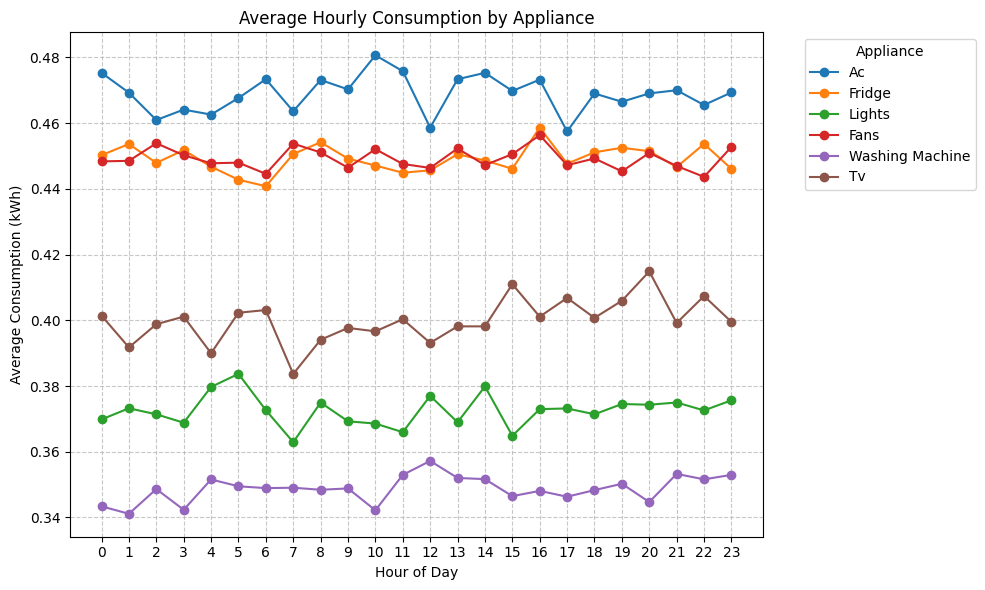

In [68]:
# Chart 1: Hourly consumption by appliance
generate_and_run_chart("Line chart showing average hourly consumption for each appliance, all on one plot with different colors and a legend.")

Generated code:
----------------------------------------
appliance_cols = ['ac', 'fridge', 'lights', 'fans', 'washing_machine', 'tv']

appliance_totals = electricity_consumption_db[appliance_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

bars = plt.bar(appliance_totals.index, appliance_totals.values, color='steelblue', edgecolor='black')

for bar, value in zip(bars, appliance_totals.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(appliance_totals.values) * 0.01,
             f'{value:,.2f} kWh', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Total Energy Consumption per Appliance', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Appliance', fontsize=13)
plt.ylabel('Total Energy Consumption (kWh)', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, max(appliance_totals.values) * 1.12)

plt.tight_layout()
plt.show()
----------------------------------------

Executing...



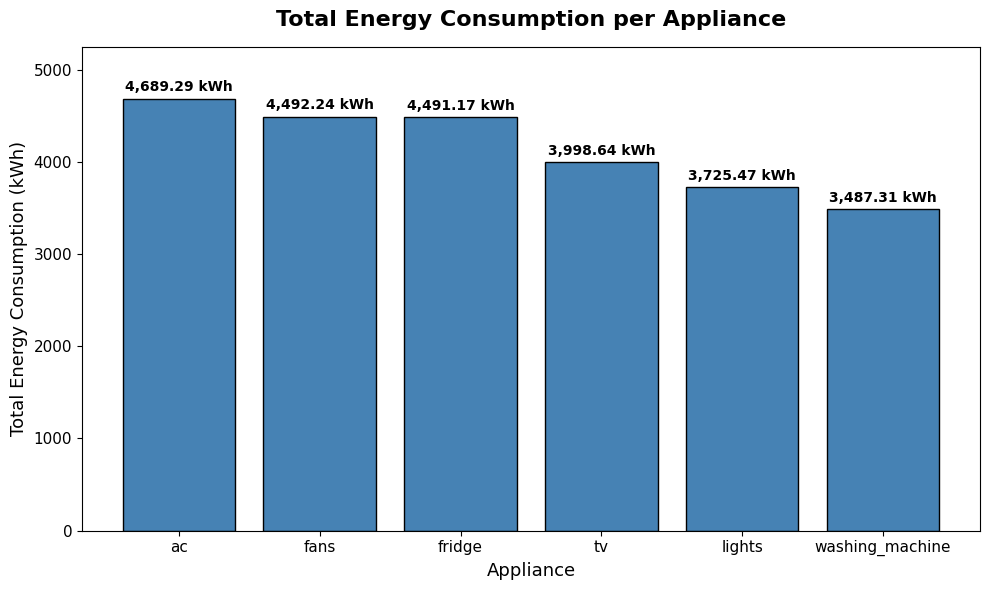

In [73]:
# Chart 2: Total energy by appliance
generate_and_run_chart("Bar chart showing total energy consumption per appliance, sorted highest to lowest, with kWh values on each bar.")

Generated code:
----------------------------------------
appliance_cols = ['ac', 'fridge', 'lights', 'fans', 'washing_machine', 'tv']

daily_avg = electricity_consumption_db.copy()
daily_avg['date'] = pd.to_datetime(daily_avg['timestamp']).dt.date
daily_seasonal = daily_avg.groupby(['date', 'season'])[appliance_cols].sum().reset_index()
seasonal_daily_avg = daily_seasonal.groupby('season')[appliance_cols].mean()

seasons = seasonal_daily_avg.index.tolist()
n_seasons = len(seasons)
n_appliances = len(appliance_cols)

import numpy as np
x = np.arange(n_seasons)
bar_width = 0.12
offsets = np.linspace(-(n_appliances - 1) / 2 * bar_width, (n_appliances - 1) / 2 * bar_width, n_appliances)

plt.figure(figsize=(10, 6))

colors = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E1D3', '#F38181', '#C9B1FF']

for i, (appliance, color, offset) in enumerate(zip(appliance_cols, colors, offsets)):
    plt.bar(x + offset, seasonal_daily_avg[appliance], width=bar_width, label=appliance.replace('_', ' ').title(), 

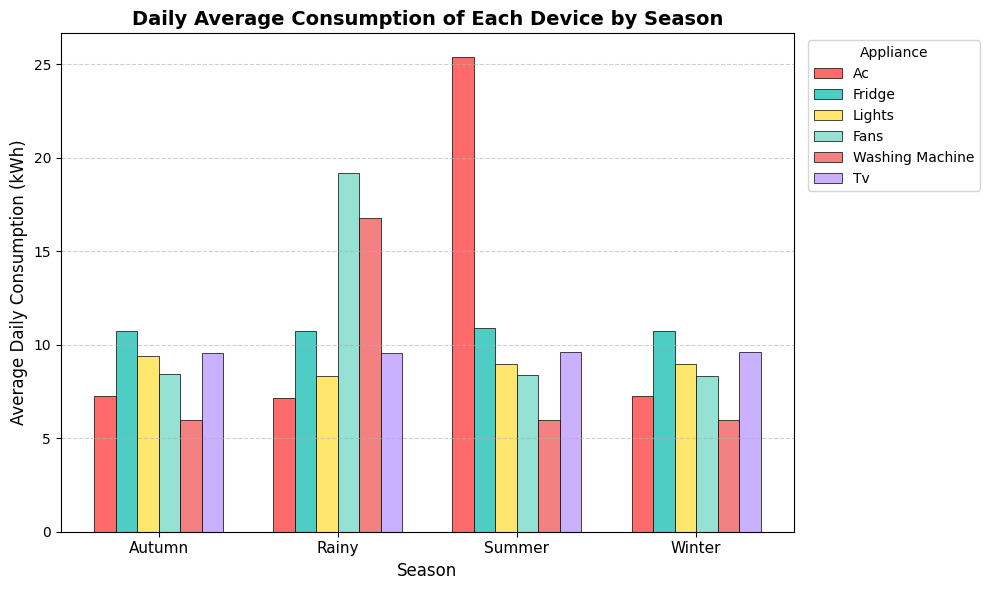

In [77]:
# Chart 3: Seasonal patterns
generate_and_run_chart("Bar chart showing daily average consumption of each device for all the seasons")